# Statistics Overview for Machine Learning

Before you feed any data into a model, you need to understand how that data is organized and what kind of values you're actually dealing with. This notebook covers the basics: what a dataset looks like, the different types of variables you'll run into, how to summarize a single variable with a frequency table, and how to visualize all of that with charts.

We'll use two datasets that ship with seaborn to keep things concrete:
- `tips` (restaurant bills) for the data table and variable-type sections.
- `flights` (monthly airline passenger counts) for the time-series / line graph section.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 1. The Data Table (Dataset)

Any dataset is basically a grid of rows and columns. Each **row** is one individual (one observation), and each **column** is one variable (one measurement about that individual).

In machine learning terms, that grid gets split into two parts:
- **X (feature matrix):** all the columns you use as inputs.
- **y (target vector):** the one column you're trying to predict.

Let's load a real dataset and look at it this way.

In [2]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Each row here is one restaurant bill (one individual). Each column (`total_bill`, `tip`, `sex`, `smoker`, `day`, `time`, `size`) is a variable, something measured about that bill.

If we were trying to predict `tip` amount from the other columns, `tip` would be our target (`y`), and everything else (`total_bill`, `sex`, `smoker`, `day`, `time`, `size`) would be our feature matrix (`X`).

In [3]:
print(f"Rows (individuals): {tips.shape[0]}")
print(f"Columns (variables): {tips.shape[1]}")
tips.columns.tolist()

Rows (individuals): 244
Columns (variables): 7


['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

## 2. Types of Variables

Every variable falls into one of two families:

- **Categorical** (labels or groups, doesn't make sense to average):
  - *Nominal*: no natural order, e.g. `sex`, `smoker`, `time` (Lunch/Dinner).
  - *Ordinal*: has an order, but the gaps between levels aren't a fixed number, e.g. a rating of Low/Medium/High.
- **Quantitative** (actual numbers you can add up or average):
  - *Discrete*: counted, whole numbers, e.g. `size` (number of people at the table).
  - *Continuous*: measured, can take any value including decimals, e.g. `total_bill`, `tip`.

Quick test: does averaging the column make sense? If yes, it's quantitative (average tip = meaningful). If no, it's categorical (average zip code = meaningless, even though a zip code is written as digits).

In [4]:
tips.dtypes

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

This lines up nicely with pandas' own dtypes: `sex`, `smoker`, `day`, and `time` are stored as `category` (nominal categorical, no order), `size` is `int64` (discrete quantitative, whole numbers), and `total_bill`/`tip` are `float64` (continuous quantitative, decimals allowed).

One trap worth remembering: some numbers are secretly categorical. A user ID or a zip code looks numeric, but it's really just a label, there's no sense in which zip code `90211` is "one more" than `90210`.

## 3. One-Way Frequency Tables

A one-way table summarizes a single categorical variable: how many times each category shows up, and what percentage of the total that is. It's called "one-way" because only one variable is being counted (a two-way table would cross two variables against each other, like `day` against `sex`).

`.value_counts()` is the pandas method that builds this for you: it counts how many rows fall into each distinct value of a column, sorted from most common to least.

**Usecase:** Here it tallies up how many bills happened on each `day`, which is the frequency table for that column.

In [5]:
day_counts = tips['day'].value_counts()
day_pct = tips['day'].value_counts(normalize=True) * 100

pd.DataFrame({'Count': day_counts, 'Percentage': day_pct.round(1)})

,Count,Percentage
day,,
Sat,87,35.7
Sun,76,31.1
Thur,62,25.4
Fri,19,7.8


## 4. Relative Frequency Tables

The "Percentage" column above is actually a **relative frequency**: instead of a raw count, it's each category's share of the whole, expressed as a proportion.

$$\text{Relative Frequency} = \frac{\text{Frequency of a category}}{\text{Total number of observations}}$$

A percentage is just that proportion multiplied by 100. Relative frequency matters most when you want to compare distributions across datasets of different sizes: raw counts aren't directly comparable (100 smokers means something different in a sample of 150 versus a sample of 10,000), but relative frequencies always are, since they're all scaled to add up to 1 (or 100%).

Passing `normalize=True` to `.value_counts()` gives you the relative frequency directly, as a proportion between 0 and 1, instead of a raw count.

In [6]:
smoker_freq = tips['smoker'].value_counts()
smoker_rel_freq = tips['smoker'].value_counts(normalize=True)

pd.DataFrame({'Frequency': smoker_freq, 'Relative Frequency': smoker_rel_freq.round(3)})

,Frequency,Relative Frequency
smoker,,
No,151,0.619
Yes,93,0.381


Reading this: a relative frequency of `0.619` for `No` means about 62% of bills were from non-smokers, exactly the same information as a percentage, just written as a fraction of 1 instead of a fraction of 100.

Relative frequency tables work just as well on a discrete quantitative column like `size` (party size), not just on obviously categorical columns.

**Usecase:** Here it shows what fraction of all bills came from each party size, so you can say "about 64% of bills are for a party of 2" regardless of whether this dataset had 244 rows or 244,000.

In [7]:
size_freq = tips['size'].value_counts().sort_index()
size_rel_freq = tips['size'].value_counts(normalize=True).sort_index()

pd.DataFrame({'Frequency': size_freq, 'Relative Frequency': size_rel_freq.round(3)})

,Frequency,Relative Frequency
size,,
1,4,0.016
2,156,0.639
3,38,0.156
4,37,0.152
5,5,0.020
6,4,0.016


Both examples above came from `tips`, where the categories are unevenly split (way more non-smokers than smokers, way more parties of 2 than any other size). It's worth seeing what a relative frequency table looks like when the categories *are* even, using `flights['month']` instead.

In [8]:
flights = sns.load_dataset('flights')

month_freq = flights['month'].value_counts().sort_index()
month_rel_freq = flights['month'].value_counts(normalize=True).sort_index()

pd.DataFrame({'Frequency': month_freq, 'Relative Frequency': month_rel_freq.round(3)})

,Frequency,Relative Frequency
month,,
Jan,12,0.083
Feb,12,0.083
Mar,12,0.083
Apr,12,0.083
May,12,0.083
Jun,12,0.083
Jul,12,0.083
Aug,12,0.083
Sep,12,0.083


Every relative frequency here comes out to `0.083` (1/12), because `flights` has exactly 12 rows for every month, one per year from 1949 to 1960. That flatness is itself useful information: it tells you this variable doesn't drive any imbalance on its own, any seasonal pattern you see later has to come from the `passengers` values, not from some months being sampled more than others.

**Usecase:** Comparing a skewed relative frequency table (`day` in `tips`) against a flat one (`month` in `flights`) is a quick way to build intuition for what "even" versus "imbalanced" categorical data actually looks like in table form, before you ever draw a chart.

## 5. Visualizing One Categorical Variable: Bar Graph

A bar graph plots a frequency table: one bar per category, height equal to the count (or percentage). The bars have visible gaps between them, that's the visual cue that you're looking at separate, unconnected categories rather than a continuous number line (bars that touch instead would make it a histogram).

`sns.countplot()` counts rows per category and draws the bars straight from the raw data, so you don't need to build the frequency table by hand first.

**Usecase:** Here it shows how many bills happened on each `day`, so you can see at a glance that Saturday and Sunday are busier than Thursday and Friday.

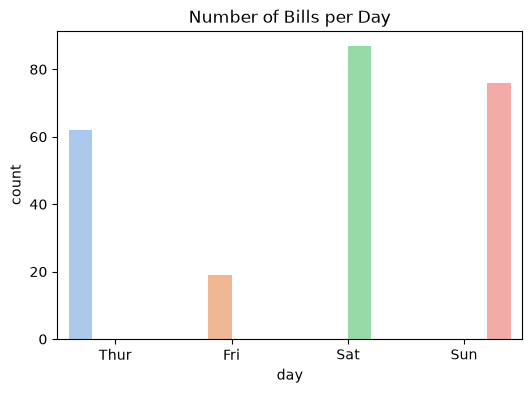

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(x='day', data=tips, hue='day', palette='pastel', legend=False, order=['Thur', 'Fri', 'Sat', 'Sun'])
plt.title('Number of Bills per Day')
plt.show()

## 6. Visualizing One Continuous Variable: The Histogram

A bar graph has gaps between its bars because each bar is a separate category. A **histogram** looks similar but the bars *touch*, because it's for continuous quantitative data, where the x-axis is one unbroken number line chopped up into equal-width ranges called **bins** (or classes), not a set of separate labels.

Plotting functions can pick bins for you automatically, but it's worth building one by hand once, so you know exactly what "number of bins" and "bin width" actually mean. We'll do that step by step on `total_bill`, then plot it.

**Step 1: Find the range.** Before deciding how wide each bin should be, you need to know the full spread of the data.

$$\text{Range} = \text{Max} - \text{Min}$$

In [10]:
bill_data = tips['total_bill']

data_min = bill_data.min()
data_max = bill_data.max()
data_range = data_max - data_min

print(f"Min: {data_min}, Max: {data_max}, Range: {data_range:.2f}")

Min: 3.07, Max: 50.81, Range: 47.74


**Step 2: Decide how many bins (k) to use.** Too few bins and the histogram hides the shape of the data (everything looks like one lump); too many and it gets noisy (every bar is its own spike). **Sturges' Rule** is a common rule of thumb for picking a reasonable number of bins from the sample size alone:

$$k = 1 + 3.322 \times \log_{10}(n)$$

In [11]:
n = len(bill_data)
k_raw = 1 + 3.322 * np.log10(n)
k = round(k_raw)

print(f"n = {n}, k (raw) = {k_raw:.2f}, k (rounded) = {k} bins")

n = 244, k (raw) = 8.93, k (rounded) = 9 bins


**Step 3: Calculate the bin width.** Divide the range by the number of bins to get the exact width each bin would need to be, then round *up* to a clean number. Rounding up (rather than to the nearest) guarantees the bins still fully cover the maximum value.

$$\text{Width} = \frac{\text{Range}}{k}$$

In [12]:
width_raw = data_range / k
width = np.ceil(width_raw)

print(f"Width (raw) = {width_raw:.2f}, Width (rounded up) = {width}")

Width (raw) = 5.30, Width (rounded up) = 6.0


**Step 4: Build the bin edges.** Start at (or just below) the minimum value, rounded down to a clean number, then keep adding the width until you have `k + 1` edges (k bins need k+1 boundary lines: a start and an end for every bin, with each bin sharing an edge with its neighbor).

In [13]:
start = np.floor(data_min)
bin_edges = [start + i * width for i in range(k + 1)]

bin_edges

[np.float64(3.0),
 np.float64(9.0),
 np.float64(15.0),
 np.float64(21.0),
 np.float64(27.0),
 np.float64(33.0),
 np.float64(39.0),
 np.float64(45.0),
 np.float64(51.0),
 np.float64(57.0)]

**Step 5: Tally the frequency table.** With the bin edges fixed, count how many values fall into each one, exactly like the one-way frequency tables from earlier, just using these calculated bins instead of categories.

In [14]:
bill_brackets = pd.cut(bill_data, bins=bin_edges, include_lowest=True)
hist_freq_table = bill_brackets.value_counts().sort_index()

hist_freq_table

total_bill
(2.999, 9.0]    12
(9.0, 15.0]     68
(15.0, 21.0]    81
(21.0, 27.0]    38
(27.0, 33.0]    24
(33.0, 39.0]    10
(39.0, 45.0]     6
(45.0, 51.0]     5
(51.0, 57.0]     0
Name: count, dtype: int64

Notice the last bin comes out empty. That's a normal side effect of rounding the width *up* to a clean number in Step 3: it slightly overshoots how much range was actually needed, so the final bin ends up with nothing in it. In practice you'd just drop that trailing empty bin; it's kept here so the calculation matches exactly what the formulas produced.

**Step 6: Visualize.** A histogram plots this exact frequency table as bars, pushed together with no gaps, since each bar is a range of a continuous variable flowing directly into the next one. `sns.histplot()` does the counting and plotting in one step, here we hand it our own `bin_edges` so it lines up exactly with the table above.

**Usecase:** The shape shows the distribution is right-skewed, most bills cluster in the $9 to $27 range, with a long thin tail of larger, less frequent bills stretching out toward $50.

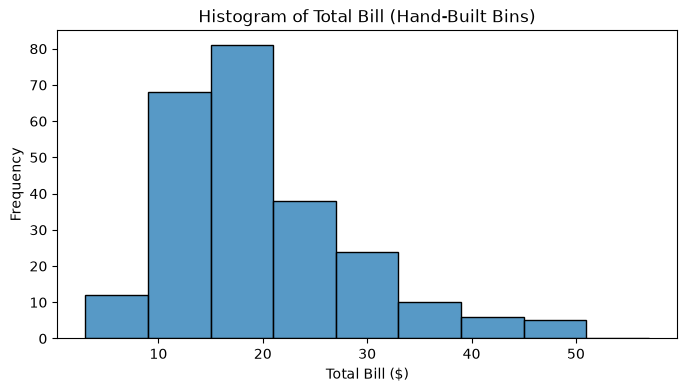

In [15]:
plt.figure(figsize=(8, 4))
sns.histplot(bill_data, bins=bin_edges, edgecolor='black')
plt.xlabel('Total Bill ($)')
plt.ylabel('Frequency')
plt.title('Histogram of Total Bill (Hand-Built Bins)')
plt.show()

In practice, you'll rarely build bins by hand like this. `sns.histplot()` (and `plt.hist()`) can pick sensible bin edges automatically if you just skip the `bins` argument, or hand it a plain integer to control roughly how many bins to use. Either way, it's the same two knobs, number of bins and bin width, just chosen for you instead of calculated by hand.

**Usecase:** Adding `kde=True` overlays a smooth curve estimating the underlying shape, useful for judging skew or spotting multiple peaks without getting distracted by any one bin's exact count.

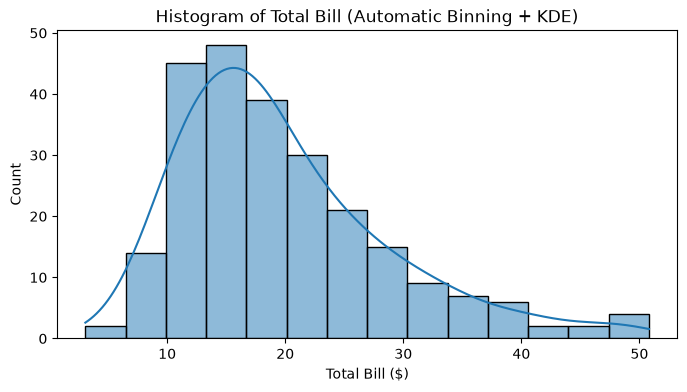

In [16]:
plt.figure(figsize=(8, 4))
sns.histplot(bill_data, kde=True)
plt.xlabel('Total Bill ($)')
plt.title('Histogram of Total Bill (Automatic Binning + KDE)')
plt.show()

**A second example, condensed.** Same six steps, run once through on the `tip` column instead of `total_bill`, just without breaking every line into its own cell this time.

In [17]:
tip_data = tips['tip']

t_min, t_max = tip_data.min(), tip_data.max()
t_range = t_max - t_min

t_n = len(tip_data)
t_k = round(1 + 3.322 * np.log10(t_n))

t_width_raw = t_range / t_k
t_width = np.ceil(t_width_raw)

t_start = np.floor(t_min)
tip_edges = [t_start + i * t_width for i in range(t_k + 1)]

print(f"Min: {t_min}, Max: {t_max}, Range: {t_range}")
print(f"n: {t_n}, k: {t_k}, Width (raw): {t_width_raw:.2f}, Width (rounded up): {t_width}")
print(f"Edges: {tip_edges}")

Min: 1.0, Max: 10.0, Range: 9.0
n: 244, k: 9, Width (raw): 1.00, Width (rounded up): 1.0
Edges: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0)]


This time the width comes out to exactly `1.0` with no rounding needed, so unlike the `total_bill` example, every bin here gets used, there's no empty trailing bin.

In [18]:
tip_brackets = pd.cut(tip_data, bins=tip_edges, include_lowest=True)
tip_freq_table = tip_brackets.value_counts().sort_index()

tip_freq_table

tip
(0.999, 2.0]    78
(2.0, 3.0]      68
(3.0, 4.0]      57
(4.0, 5.0]      23
(5.0, 6.0]      11
(6.0, 7.0]       4
(7.0, 8.0]       1
(8.0, 9.0]       1
(9.0, 10.0]      1
Name: count, dtype: int64

**Usecase:** Even more right-skewed than `total_bill` was: tips of \$1 to \$2 alone make up almost a third of all bills, and the counts drop off fast after that, with only a handful of tips above \$6. That's the kind of shape a histogram makes obvious in one glance but is much harder to spot by scanning a table of raw numbers.

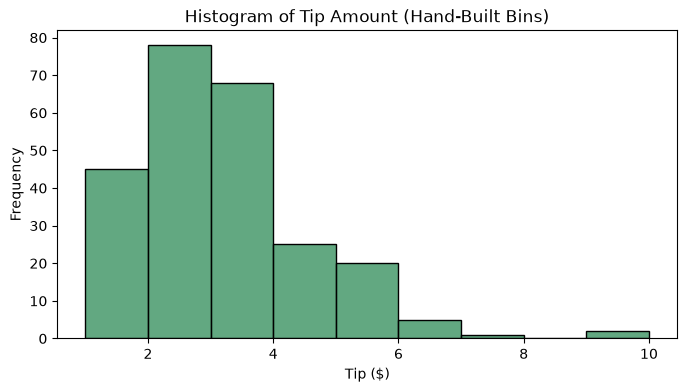

In [19]:
plt.figure(figsize=(8, 4))
sns.histplot(tip_data, bins=tip_edges, edgecolor='black', color='seagreen')
plt.xlabel('Tip ($)')
plt.ylabel('Frequency')
plt.title('Histogram of Tip Amount (Hand-Built Bins)')
plt.show()

**A third example, with other datasets.** Everything above used one dataset (`tips`) so the six-step process stayed easy to follow. Here are the same histogram ideas applied to other seaborn datasets, mainly to show how a couple of extra `histplot` arguments connect back to concepts already covered earlier in this notebook.

### Comparing Groups on One Histogram

`sns.load_dataset('iris')` loads 150 flower measurements across 3 species. Passing `hue='species'` colors the bars by species, and `multiple='stack'` piles them on top of each other in the same bin instead of drawing separate overlapping histograms.

In [20]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


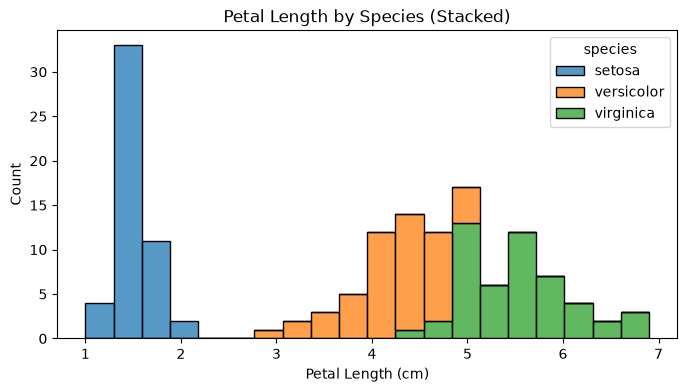

In [21]:
plt.figure(figsize=(8, 4))
sns.histplot(data=iris, x='petal_length', hue='species', multiple='stack', bins=20)
plt.xlabel('Petal Length (cm)')
plt.title('Petal Length by Species (Stacked)')
plt.show()

**Usecase:** `setosa` sits in its own bin range with almost no overlap with the other two species, which is exactly the kind of separation a one-way frequency table on `species` alone could never show you, you need the quantitative column plotted alongside the category to see it.

### Histogram on a Density Scale (Ties Back to Section 4)

By default a histogram's y-axis is a raw count, same as the plain frequency tables from Section 3. Setting `stat='density'` rescales the bars so the total area under them adds up to 1, the histogram equivalent of the **relative frequency** tables from Section 4, just spread across continuous bins instead of discrete categories.

`sns.load_dataset('penguins')` loads body measurements for 3 penguin species. Since `Gentoo` has noticeably more rows than the other two species here, comparing raw counts would unfairly make `Gentoo` look "bigger" in every bin just because there's more of it, `stat='density'` fixes that the same way `normalize=True` fixed it for the one-way tables earlier.

In [22]:
penguins = sns.load_dataset('penguins')
print(penguins['species'].value_counts())
penguins.head()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


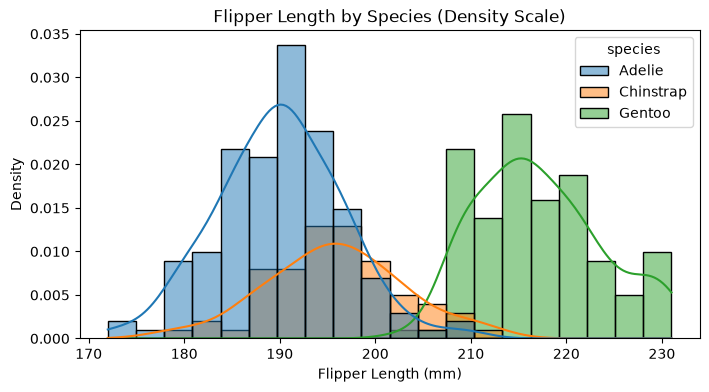

In [23]:
plt.figure(figsize=(8, 4))
sns.histplot(data=penguins, x='flipper_length_mm', hue='species', stat='density', kde=True, bins=20)
plt.xlabel('Flipper Length (mm)')
plt.title('Flipper Length by Species (Density Scale)')
plt.show()

### A Heavily Skewed Histogram

`sns.load_dataset('diamonds')` loads about 54,000 diamond sales. Its `price` column is heavily right-skewed (like `tip` above, just far more extreme), most diamonds are cheap and a small number are very expensive, so a normal histogram squashes almost every bar into the leftmost bin. `log_scale=True` spaces the x-axis bins by powers of 10 instead of equal dollar amounts, which pulls the squashed end back apart so the shape is actually readable.

In [24]:
diamonds = sns.load_dataset('diamonds')
print("Rows:", len(diamonds))
diamonds.head()

Rows: 53940


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


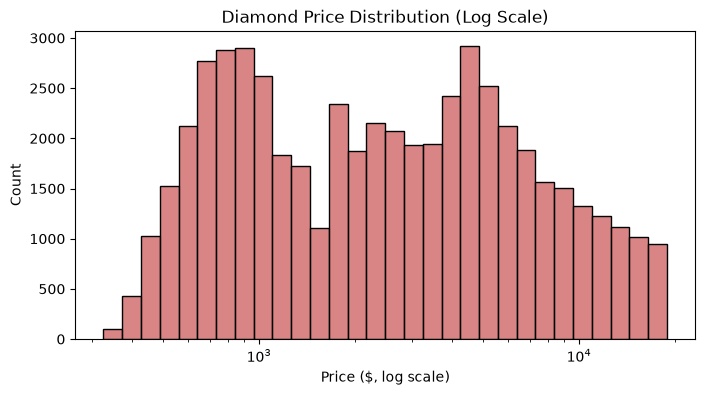

In [25]:
plt.figure(figsize=(8, 4))
sns.histplot(diamonds['price'], log_scale=True, bins=30, color='indianred')
plt.xlabel('Price ($, log scale)')
plt.title('Diamond Price Distribution (Log Scale)')
plt.show()

## 7. Visualizing Parts of a Whole: Pie Chart

Where a bar graph compares categories against each other, a pie chart shows how each category shares the total (the full circle is 100%, or 360 degrees). Seaborn doesn't include a pie chart function, it's built for statistical relationships rather than part-to-whole breakdowns, so this one uses plain matplotlib instead.

**Usecase:** Here it shows what share of all bills happened on each day. This kind of chart reads best with just a handful of categories (like our 4 days); with 20 categories the slices would be too thin to compare.

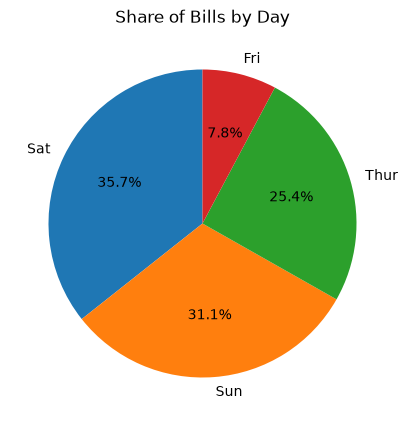

In [26]:
plt.figure(figsize=(5, 5))
plt.pie(day_counts, labels=day_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Share of Bills by Day')
plt.show()

## 8. Visualizing Trends Over Time: Line Graph

A line graph connects data points in order (usually over time) so you can see whether something is trending up, down, or staying flat. That needs a real sequence on the x-axis, which `tips` doesn't have, so we'll switch to seaborn's `flights` dataset instead: monthly airline passenger counts from 1949 to 1960.

In [27]:
flights = sns.load_dataset('flights')
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


Each row here is one individual month (e.g. "January 1949"). `year` and `month` together give us the ordered sequence we plot on the x-axis, and `passengers` is the quantitative value we're tracking over that sequence.

This is also a nice real example of an ordinal variable: `month` has a genuine order (Jan comes before Feb comes before Mar...), even though it's stored as a category rather than a number.

`sns.lineplot()` draws a line connecting the average `y` value for each `x` value, plus a shaded confidence band around it (turned off below with `errorbar=None` since there's only one row per year-month combination anyway, so there's no spread to show).

**Usecase:** Here it plots total air travel by year, and the line slopes clearly upward, showing air travel growing steadily through the 1950s.

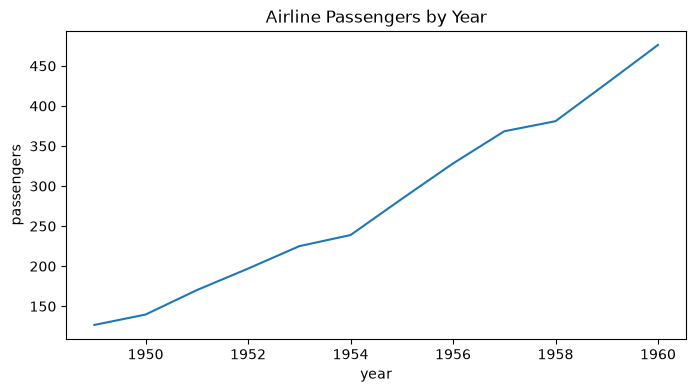

In [28]:
plt.figure(figsize=(8, 4))
sns.lineplot(x='year', y='passengers', data=flights, errorbar=None)
plt.title('Airline Passengers by Year')
plt.show()

You can also check for a repeating pattern within each year (seasonality) by plotting `passengers` against `month` instead, drawing one line per `year` with `hue`.

**Usecase:** This shows the same summer travel peak showing up every single year, and the lines climbing higher year over year as overall demand grows.

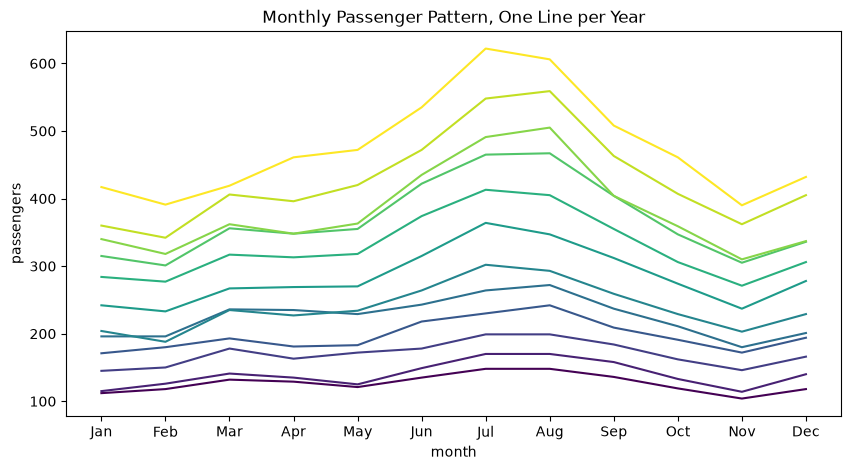

In [29]:
plt.figure(figsize=(10, 5))
sns.lineplot(x='month', y='passengers', data=flights, hue='year', palette='viridis', legend=False)
plt.title('Monthly Passenger Pattern, One Line per Year')
plt.show()

## 9. Cumulative Frequency: The Ogive

An ogive (pronounced "oh-jive") is a line graph of **cumulative frequency**: instead of showing how many values fall into each bracket on its own, it shows a running total as you move through the brackets from lowest to highest.

To build one for a continuous variable like `total_bill`, you first have to group the raw values into class intervals (brackets), since "every possible dollar amount" isn't a usable set of categories. `pd.cut()` is the pandas function that does that grouping: you give it a list of bin edges, and it slots every value into the bracket it falls in. This is exactly the same binning idea as the histogram above, just carried one step further into a running total.

Once you have a frequency count per bracket, `.cumsum()` turns that into a running total: each bracket's cumulative frequency is its own count plus everyone before it.

In [30]:
bill_bins = [0, 10, 20, 30, 40, 50, 60]
tips['bill_bracket'] = pd.cut(tips['total_bill'], bins=bill_bins)

freq_table = tips['bill_bracket'].value_counts().sort_index()
cum_freq = freq_table.cumsum()

pd.DataFrame({'Frequency': freq_table, 'Cumulative Frequency': cum_freq})

,Frequency,Cumulative Frequency
bill_bracket,,
"(0, 10]",17,17
"(10, 20]",130,147
"(20, 30]",65,212
"(30, 40]",22,234
"(40, 50]",9,243
"(50, 60]",1,244


Now plot the cumulative frequency against the **upper edge** of each bracket, connecting the points with a line. An ogive always slopes upward or stays flat, never downward, because a running total can't shrink as you add more brackets.

**Usecase:** An ogive lets you answer "about how many bills were under $X" just by reading the curve, e.g. finding $30 on the x-axis and reading straight up to see roughly 212 bills were $30 or less.

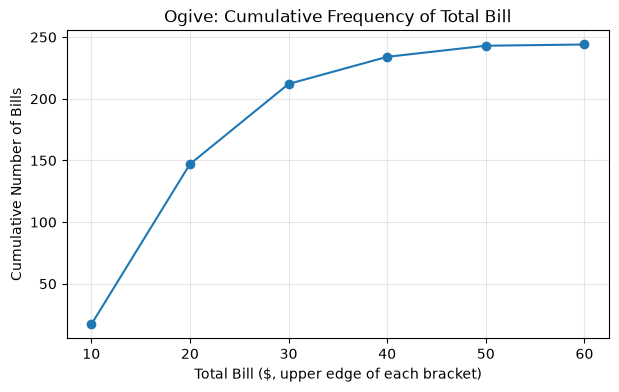

In [31]:
upper_bounds = bill_bins[1:]

plt.figure(figsize=(7, 4))
plt.plot(upper_bounds, cum_freq.values, marker='o')
plt.xlabel('Total Bill ($, upper edge of each bracket)')
plt.ylabel('Cumulative Number of Bills')
plt.title('Ogive: Cumulative Frequency of Total Bill')
plt.grid(True, alpha=0.3)
plt.show()

## 10. Two-Way Tables (Cross-Tabulation)

A one-way table counts one variable on its own. A **two-way table** (also called a contingency table) counts two categorical variables at the same time, so you can see how they relate to each other, not just each one separately.

`pd.crosstab()` is the pandas function that builds this directly from two columns: one variable's categories become the rows, the other's become the columns, and each cell is the count of rows that match both.

**Usecase:** Here it cross-tabulates `day` against `smoker`, so instead of just knowing how many bills happened on each day, or how many smokers there were overall, you can see the smoker/non-smoker split within each specific day.

In [32]:
two_way = pd.crosstab(tips['day'], tips['smoker'])
two_way

smoker,Yes,No
day,,
Thur,17,45
Fri,15,4
Sat,42,45
Sun,19,57


Adding `margins=True` tacks on row and column totals. Those totals are called **marginal distributions**: the `Total` row is just the one-way frequency table of `smoker` on its own (ignoring `day`), and the `Total` column is the one-way frequency table of `day` on its own (ignoring `smoker`). They're literally sitting in the margins of the two-way table, which is where the name comes from.

In [33]:
pd.crosstab(tips['day'], tips['smoker'], margins=True, margins_name='Total')

smoker,Yes,No,Total
day,,,
Thur,17,45,62
Fri,15,4,19
Sat,42,45,87
Sun,19,57,76
Total,93,151,244


Now divide every cell by the **grand total** instead of a row or column total. That gives you the **joint distribution** of `day` and `smoker` together: what fraction of *all* 244 bills fall into each specific day-and-smoker combination. `pd.crosstab(..., normalize='all')` does exactly that.

This is a different question from the row percentages further down: the joint distribution asks "what share of every single bill is Sunday-and-non-smoking?", while the row-normalized version asks "of the bills that happened on Sunday specifically, what share were non-smoking?" A joint distribution's cells always add up to 1 across the *whole* table, not row by row.

**Usecase:** Here it shows that Sunday, non-smoking bills alone make up about 23% of every bill in the dataset, the single biggest day-and-smoker combination there is.

In [34]:
joint_dist = pd.crosstab(tips['day'], tips['smoker'], normalize='all')
joint_dist.round(3)

smoker,Yes,No
day,,
Thur,0.070,0.184
Fri,0.061,0.016
Sat,0.172,0.184
Sun,0.078,0.234


A 2x2 table makes the idea even easier to see. Here's the joint distribution of `sex` and `smoker`: four combinations in total, and since every bill has exactly one `sex` and one `smoker` value, the four numbers below have to add up to 1.

In [35]:
joint_sex_smoker = pd.crosstab(tips['sex'], tips['smoker'], normalize='all')
joint_sex_smoker.round(3)

smoker,Yes,No
sex,,
Male,0.246,0.398
Female,0.135,0.221


**Usecase:** The biggest single slice is Male-and-non-smoker at about 40% of all bills, roughly triple the size of the smallest slice (Female-and-smoker, about 14%). Notice this doesn't tell you whether men are *more likely* to be non-smokers than women, that's a conditional-distribution question (normalize by row or column), not a joint-distribution one, the joint distribution only tells you each combination's share of the grand total.

Raw counts can be misleading here, since Friday just has far fewer bills overall than Saturday. Passing `normalize='index'` turns each row into percentages that add up to 100, so you can fairly compare the smoker/non-smoker split within each day, regardless of how busy that day was. This row-normalized version is called the **conditional distribution** of `smoker` given `day`, it's the distribution of one variable once you've already fixed the other.

**Usecase:** This makes it obvious that Friday has the highest share of smokers proportionally, even though it has the fewest total bills of any day.

In [36]:
two_way_pct = pd.crosstab(tips['day'], tips['smoker'], normalize='index') * 100
two_way_pct.round(1)

smoker,Yes,No
day,,
Thur,27.4,72.6
Fri,78.9,21.1
Sat,48.3,51.7
Sun,25.0,75.0


`sns.heatmap()` turns a table of numbers into a grid of colored cells, where a darker (or lighter, depending on the color scale) cell means a bigger number. That makes it possible to spot the biggest and smallest cells in a two-way table at a glance, instead of scanning every number.

**Usecase:** Here it visualizes the same `day` vs `smoker` counts, making Saturday's non-smoker count immediately stand out as the darkest cell.

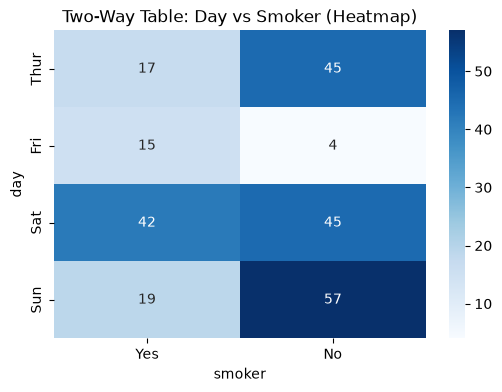

In [37]:
plt.figure(figsize=(6, 4))
sns.heatmap(two_way, annot=True, fmt='d', cmap='Blues')
plt.title('Two-Way Table: Day vs Smoker (Heatmap)')
plt.show()

## 11. Dot Plot

A dot plot shows every individual value of a quantitative variable as one dot on a number line. When several observations share the same value, their dots stack up on top of each other at that spot. It's basically a frequency table where the bars are replaced by literal, stacked, individual dots, one per observation, so it works best when there are only a handful of distinct values to stack.

This is different from a scatter plot (which plots two variables against each other) and from `sns.stripplot()` (which jitters points sideways so they don't overlap). A true dot plot keeps every dot on the exact same vertical line and stacks them cleanly instead.

`size` (party size) is a good fit here: it's discrete, and only takes values 1 through 6. Matplotlib doesn't have a ready-made dot plot function, so this builds one directly: for each party size, plot one dot per bill, stacked at increasing heights.

**Usecase:** With only 6 possible party sizes, you can almost count the dots directly to see that parties of 2 are by far the most common, without needing any binning or averaging.

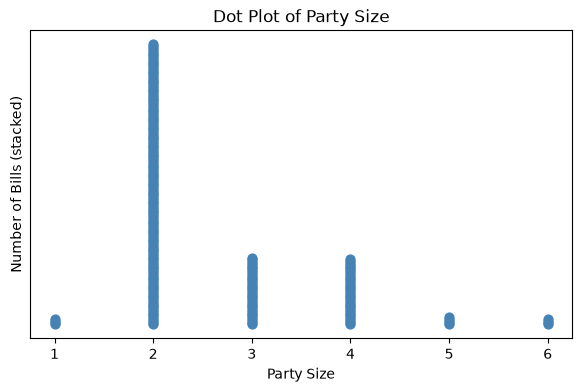

In [38]:
size_counts = tips['size'].value_counts().sort_index()

plt.figure(figsize=(7, 4))
for size_value, count in size_counts.items():
    plt.scatter([size_value] * count, range(1, count + 1), color='steelblue', s=40)

plt.xlabel('Party Size')
plt.ylabel('Number of Bills (stacked)')
plt.title('Dot Plot of Party Size')
plt.yticks([])
plt.show()

## 12. Detecting Outliers in Array Data

An **outlier** is a value that sits far away from the rest of the data, either a genuine rare case or a data-entry mistake worth double-checking. Outliers matter in ML because the mean and standard deviation are both sensitive to them (one huge value can drag the average up and inflate the spread), and distance-based models like KNN or k-means can end up organizing everything around a handful of extreme points instead of the actual pattern in the data.

### Method 1: The IQR (Interquartile Range) Rule

$Q1$ and $Q3$ are the 25th and 75th percentiles, the interquartile range is the width of the middle 50% of the data:

$$IQR = Q3 - Q1$$

Anything below the lower bound or above the upper bound counts as an outlier:

$$\text{Lower bound} = Q1 - 1.5 \times IQR$$
$$\text{Upper bound} = Q3 + 1.5 \times IQR$$

The `1.5` multiplier is a convention, the same way Sturges' Rule was a convention for picking bin counts, not a hard mathematical law.

In [39]:
heights = np.array([158, 162, 165, 168, 170, 172, 175, 178, 180, 210])
heights

array([158, 162, 165, 168, 170, 172, 175, 178, 180, 210])

In [40]:
q1, q3 = np.percentile(heights, [25, 75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

Q1: 165.75, Q3: 177.25, IQR: 11.5
Lower bound: 148.5, Upper bound: 194.5


In [41]:
outlier_mask = (heights < lower_bound) | (heights > upper_bound)
heights[outlier_mask]

array([210])

**Usecase:** `210` gets flagged because it sits above the upper bound of `194.5`, more than 20 units past where the rest of the group tops out (`180`). Everything else falls comfortably inside the bounds, so nothing else gets flagged.

## One More Examples for outliers

In [46]:
arr = np.array([2,3,4,6,7,8,9,12,13,16,17,23,25,27,34,37,201])
arr

array([  2,   3,   4,   6,   7,   8,   9,  12,  13,  16,  17,  23,  25,
        27,  34,  37, 201])

In [47]:
Q1 = np.percentile(arr, 25)
Q3 = np.percentile(arr, 75)

IQR = Q3 - Q1
IQR

np.float64(18.0)

In [49]:
UF = Q3 + (1.5*IQR)
LF = Q1 - (1.5*IQR)

In [62]:
l = []
for i in arr:
    if i >= LF and i <= UF:
        l.append(i)
updated_arr = np.array(l)

In [63]:
print(arr)
print(updated_arr)


[  2   3   4   6   7   8   9  12  13  16  17  23  25  27  34  37 201]
[ 2  3  4  6  7  8  9 12 13 16 17 23 25 27 34 37]


<Axes: >

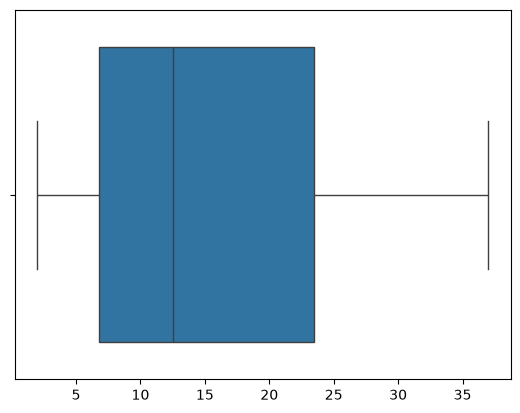

In [66]:
import seaborn as sns

# sns.boxplot(x = arr)
sns.boxplot(x = updated_arr)

### Applying It to a Real Column

Same rule, just using `.quantile()` on a pandas Series instead of `np.percentile()` on a plain array, applied to `total_bill` from `tips`.

In [42]:
bill = tips['total_bill']

q1, q3 = bill.quantile(0.25), bill.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

bill_outliers = tips[(bill < lower_bound) | (bill > upper_bound)]
print(f"Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Outliers found: {len(bill_outliers)} out of {len(tips)} bills")
bill_outliers[['total_bill', 'tip', 'size']]

Bounds: [-2.82, 40.30]
Outliers found: 9 out of 244 bills


,total_bill,tip,size
59,48.27,6.73,4
102,44.30,2.50,3
142,41.19,5.00,5
156,48.17,5.00,6
170,50.81,10.00,3
182,45.35,3.50,3
184,40.55,3.00,2
197,43.11,5.00,4
212,48.33,9.00,4


**Usecase:** 9 out of 244 bills get flagged, all of them well above the upper bound rather than below it, which lines up with `total_bill` being right-skewed (established back in Section 6): a few unusually large bills, no unusually small ones.

`sns.boxplot()` draws exactly these bounds for you: the box is `Q1` to `Q3`, the whiskers stretch out to the lower/upper bound, and any point past the whiskers is plotted individually, one dot per outlier.

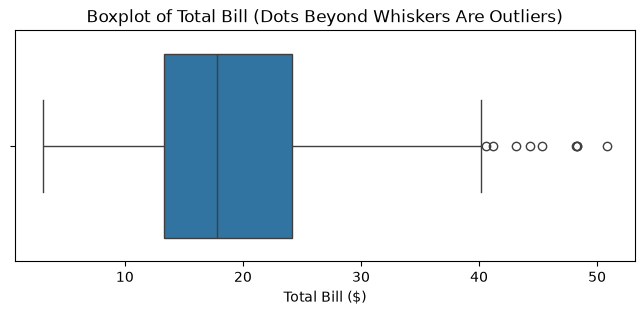

In [43]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=tips['total_bill'])
plt.xlabel('Total Bill ($)')
plt.title('Boxplot of Total Bill (Dots Beyond Whiskers Are Outliers)')
plt.show()

## Key Takeaways

- A dataset is a grid: rows are individuals, columns are variables. In ML, that splits into features (`X`) and a target (`y`).
- Every variable is either categorical (nominal or ordinal) or quantitative (discrete or continuous). Ask "does averaging it make sense?" to tell which.
- A one-way frequency table (`.value_counts()`) summarizes one categorical variable as counts. A relative frequency table expresses those same counts as proportions of the total, which is what makes them comparable across datasets of different sizes.
- Bar graphs compare categories against each other (gaps between bars). A histogram is the continuous-variable version of the same idea (bars touching, since the x-axis is one unbroken number line split into bins); Sturges' Rule (`k = 1 + 3.322*log10(n)`) is a common way to pick how many bins to use. Pie charts show how each category shares a whole (best with a handful of categories). Line graphs show trends over an ordered sequence like time. An ogive is a line graph of *cumulative* frequency, always sloping upward.
- A two-way table (`pd.crosstab()`) crosses two categorical variables at once. Its grand-total percentages are the **joint distribution**, its row/column totals are the **marginal distributions**, and its row- or column-normalized percentages are the **conditional distribution**.
- A dot plot stacks one dot per observation along a number line, good for a small number of distinct quantitative values.
- These are the same checks you lean on early in any ML project: a histogram to see the shape of a numeric feature, a bar chart to spot class imbalance in your target, a two-way table to check whether that imbalance interacts with another feature, a line graph to watch a loss curve during training.
- An outlier sits far from the rest of the data. The **IQR rule** (outside `Q1 - 1.5*IQR` to `Q3 + 1.5*IQR`) makes no assumption about the data's shape, which is what `sns.boxplot()` draws as whiskers. The **z-score rule** (`|z| > 3`) assumes a roughly normal, symmetric distribution, so it tends to under-count outliers on skewed data.
